# Wall Segmentation Pipeline

Room point cloud → vertical-surface filter → normal-direction clustering →
offset clustering → per-wall point clouds.

**Input:** a single room's point cloud (e.g. `room_XX_walls.ply` from
RoomSegmentation, or any `.ply`/`.xyz` containing one room).

**How this notebook is organised**

1. **Setup** – installs, imports.
2. **Config** – one dataclass holds every tunable parameter.
3. **Definitions** – pure functions: `segment_walls` and helpers.
4. **Run** – thin driver cells that wire the stages together.

## 0 · Environment setup

In [ ]:
!pip install -q open3d scipy

### Mount Google Drive (if running on Colab)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Imports

In [ ]:
import os
import math
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import open3d as o3d

## 1 · Configuration

In [ ]:
@dataclass
class Config:
    # ---- input ----
    # single file for interactive use:
    file_path: str = '/content/drive/MyDrive/ONESTRUCTION/room_01_walls.ply'
    # glob pattern for batch processing all rooms:
    room_glob: str = '/content/drive/MyDrive/ONESTRUCTION/room_*_walls.ply'
    up_axis: int = 2                        # 0=X, 1=Y, 2=Z

    # ---- preprocessing ----
    voxel_m: float = 0.02                   # downsample voxel size (metres)
    normal_radius_m: float = 0.10           # radius for normal estimation
    normal_max_nn: int = 30                 # max neighbours for normal estimation

    # ---- vertical filter ----
    normal_tol_deg: float = 10.0            # max tilt from vertical to count as wall

    # ---- direction clustering ----
    angle_tol_deg: float = 10.0             # angular bin width for grouping wall normals

    # ---- offset clustering (splits parallel walls) ----
    offset_tol_m: float = 0.15              # > wall thickness (~0.10-0.15), < room width

    # ---- minimum size ----
    min_wall_points: int = 500              # drop clusters with fewer points

    # ---- wall image rasterisation ----
    flat_pixel_m: float = 0.02              # pixel size for wall frontal images

    # ---- output ----
    out_dir: str = '/content/wall_seg_out'


CFG = Config()
print(f"Single file : {CFG.file_path}")
print(f"Batch glob  : {CFG.room_glob}")
print(f"Up axis: {CFG.up_axis}  |  angle_tol: {CFG.angle_tol_deg}°  |  offset_tol: {CFG.offset_tol_m} m")

## 2 · Definitions

### Load & preprocess

In [12]:
def load_room_cloud(file_path, voxel_m=0.02):
    """Read a room point cloud, downsample, return (pcd, points)."""
    pcd = o3d.io.read_point_cloud(file_path)
    pts = np.asarray(pcd.points)
    assert len(pts) > 0, f"Empty cloud: {file_path}"
    print(f"Loaded {len(pts):,} points from {os.path.basename(file_path)}")

    if voxel_m > 0:
        pcd = pcd.voxel_down_sample(voxel_m)
        pts = np.asarray(pcd.points)
        print(f"After voxel downsample ({voxel_m} m): {len(pts):,} points")

    return pcd, pts

### Core: wall segmentation

**Algorithm:**

1. Estimate normals, keep only points whose normal is roughly horizontal
   (within `normal_tol_deg` of the horizontal plane) — this drops
   floor, ceiling, and non-wall clutter.
2. Compute each point's horizontal normal angle θ ∈ [0°, 180°). Opposite-
   facing normals are folded so both sides of a wall merge.
3. Cluster by θ → one group per wall orientation.
4. Within each direction group, project onto the group's mean normal to get
   a 1-D offset, then cluster by offset → separates parallel walls.

In [29]:
from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d


def _cluster_1d_gaps(values, tol):
    """Split sorted values at gaps > tol. Used for offset clustering
    where the data has natural gaps between parallel walls."""
    if len(values) == 0:
        return np.array([], dtype=int)
    order = np.argsort(values)
    sorted_v = values[order]
    labels_sorted = np.zeros(len(sorted_v), dtype=int)
    label = 0
    for i in range(1, len(sorted_v)):
        if sorted_v[i] - sorted_v[i - 1] > tol:
            label += 1
        labels_sorted[i] = label
    result = np.empty(len(values), dtype=int)
    result[order] = labels_sorted
    return result


def _find_angle_peaks(theta, n_bins=180, smooth_width=7, min_height_frac=0.05):
    """Find dominant angle modes via a smoothed circular histogram.

    Returns peak centres (radians) in [0, π). Works even when noise fills
    the gaps between wall directions — peaks still rise above the noise floor.
    """
    counts, edges = np.histogram(theta, bins=n_bins, range=(0, np.pi))
    centres = 0.5 * (edges[:-1] + edges[1:])

    # circular-aware smoothing: tile, smooth, untile
    tiled = np.concatenate([counts, counts, counts])
    smoothed_tiled = uniform_filter1d(tiled.astype(float), size=smooth_width)
    smoothed = smoothed_tiled[n_bins:2*n_bins]

    height_thr = smoothed.max() * min_height_frac
    # min distance between peaks: walls are typically ≥ 20° apart
    min_dist = max(1, int(20 / (180 / n_bins)))
    peaks, props = find_peaks(smoothed, height=height_thr, distance=min_dist)

    return centres[peaks], smoothed, centres


def _assign_to_nearest_peak(theta, peak_centres):
    """Assign each angle to the nearest peak, respecting circular wrap at π."""
    labels = np.empty(len(theta), dtype=int)
    for i, t in enumerate(theta):
        dists = np.minimum(np.abs(peak_centres - t),
                           np.pi - np.abs(peak_centres - t))
        labels[i] = np.argmin(dists)
    return labels


def segment_walls(pcd, up_axis=2, normal_tol_deg=10.0,
                  angle_tol_deg=10.0, offset_tol=0.15,
                  min_wall_points=500,
                  normal_radius=0.10, normal_max_nn=30):
    """Segment a room point cloud into individual wall clusters.

    Uses histogram peak detection for angle clustering (robust to noisy
    normals), then gap-based clustering on the 1-D offset within each
    direction group to separate parallel walls.

    Returns a list of dicts, each with:
        'cloud'     — o3d.geometry.PointCloud for this wall
        'normal_2d' — [n_a, n_b] mean horizontal normal of this wall
        'offset'    — mean signed distance along that normal
        '_theta_peaks' — (attached once) peak centres for diagnostics
        '_theta_smooth' — (attached once) smoothed histogram for diagnostics
        '_theta_centres' — (attached once) bin centres for diagnostics
    """
    if len(pcd.points) < min_wall_points:
        print("Too few points for wall segmentation.")
        return []

    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=normal_radius, max_nn=normal_max_nn))

    pts = np.asarray(pcd.points)
    norms = np.asarray(pcd.normals)

    # 1. keep vertical-ish normals
    up = np.zeros(3)
    up[up_axis] = 1.0
    cos_with_up = np.abs(norms @ up)
    sin_tol = np.sin(np.deg2rad(normal_tol_deg))
    vert_mask = cos_with_up < sin_tol

    pts_v = pts[vert_mask]
    norms_v = norms[vert_mask]
    print(f"Vertical-surface points: {len(pts_v):,} / {len(pts):,} "
          f"({100 * len(pts_v) / len(pts):.1f}%)")

    if len(pts_v) < min_wall_points:
        print("Too few vertical points.")
        return []

    # 2. horizontal normal angle θ ∈ [0, π)
    ha, hb = [a for a in range(3) if a != up_axis]
    nh = norms_v[:, [ha, hb]].copy()
    nh /= (np.linalg.norm(nh, axis=1, keepdims=True) + 1e-9)
    theta = np.arctan2(nh[:, 1], nh[:, 0]) % np.pi

    # 3. find dominant angle peaks via histogram
    peak_centres, smoothed, bin_centres = _find_angle_peaks(theta)
    print(f"Angle peaks: {len(peak_centres)}  at "
          f"{[f'{np.degrees(p):.1f}°' for p in peak_centres]}")

    if len(peak_centres) == 0:
        print("No angle peaks found — try lowering min_height_frac.")
        return []

    angle_labels = _assign_to_nearest_peak(theta, peak_centres)
    n_dirs = len(peak_centres)
    print(f"Direction groups: {n_dirs}")

    # 4. within each direction group, cluster by offset
    walls = []
    for a_label in range(n_dirs):
        a_mask = angle_labels == a_label
        a_pts = pts_v[a_mask]
        a_nh = nh[a_mask]

        mean_n = a_nh.mean(axis=0)
        mean_n /= (np.linalg.norm(mean_n) + 1e-9)

        offsets = a_pts[:, ha] * mean_n[0] + a_pts[:, hb] * mean_n[1]
        off_labels = _cluster_1d_gaps(offsets, offset_tol)

        for o_label in np.unique(off_labels):
            o_mask = off_labels == o_label
            wall_pts = a_pts[o_mask]
            if len(wall_pts) < min_wall_points:
                continue

            cloud = o3d.geometry.PointCloud()
            cloud.points = o3d.utility.Vector3dVector(wall_pts)
            if pcd.has_colors():
                colors_v = np.asarray(pcd.colors)[vert_mask]
                cloud.colors = o3d.utility.Vector3dVector(colors_v[a_mask][o_mask])

            walls.append({
                'cloud': cloud,
                'normal_2d': mean_n.copy(),
                'offset': float(offsets[o_mask].mean()),
            })

    # stash diagnostics on the first wall so the plot cell can grab them
    if walls:
        walls[0]['_theta_peaks'] = peak_centres
        walls[0]['_theta_smooth'] = smoothed
        walls[0]['_theta_centres'] = bin_centres

    print(f"Walls found: {len(walls)}")
    return walls

### Visualisation helpers

In [30]:
def plot_walls_3d(walls, up_axis=2, max_pts_per_wall=5000):
    """3-D scatter with each wall in a different colour."""
    if not walls:
        print("No walls to plot.")
        return

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    rng = np.random.default_rng(42)

    for i, w in enumerate(walls):
        pts = np.asarray(w['cloud'].points)
        if len(pts) > max_pts_per_wall:
            idx = rng.choice(len(pts), max_pts_per_wall, replace=False)
            pts = pts[idx]
        color = rng.random(3)
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
                   s=0.4, c=[color], label=f"wall {i+1} ({len(w['cloud'].points):,})")

    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_title(f"Segmented walls ({len(walls)})")
    ax.legend(markerscale=10, loc="upper right", fontsize=8)
    ax.set_box_aspect([1, 1, 1])
    plt.tight_layout()
    plt.show()


def plot_walls_topdown(walls, up_axis=2, max_pts_per_wall=5000):
    """Top-down (bird's-eye) view of segmented walls."""
    if not walls:
        print("No walls to plot.")
        return

    ha, hb = [a for a in range(3) if a != up_axis]
    ax_name = {0: "X", 1: "Y", 2: "Z"}

    fig, ax = plt.subplots(figsize=(10, 10))
    rng = np.random.default_rng(42)

    for i, w in enumerate(walls):
        pts = np.asarray(w['cloud'].points)
        if len(pts) > max_pts_per_wall:
            idx = rng.choice(len(pts), max_pts_per_wall, replace=False)
            pts = pts[idx]
        color = rng.random(3)
        ax.scatter(pts[:, ha], pts[:, hb], s=0.4, c=[color],
                   label=f"wall {i+1}")

    ax.set_xlabel(ax_name.get(ha, str(ha)))
    ax.set_ylabel(ax_name.get(hb, str(hb)))
    ax.set_title("Walls — top-down view")
    ax.legend(markerscale=10, fontsize=8)
    ax.set_aspect("equal", adjustable="datalim")
    plt.tight_layout()
    plt.show()

### Wall flattening — project each wall to a 2D frontal image

For each wall, build a local coordinate frame:
- **u** — horizontal, along the wall surface (perpendicular to the normal in the ground plane)
- **v** — vertical (the up axis)

Project every point onto (u, v), then rasterize into a density grid.
Doors and windows show up as rectangular voids (low-density regions).

In [ ]:
from PIL import Image
import glob


def flatten_wall(wall, up_axis=2, pixel_m=0.02, min_pts_per_cell=1):
    """Project a wall's 3D points onto its plane → 2D occupancy image.

    Returns dict with:
        'image'    — uint8 array (0=wall/occupied, 255=void), oriented so
                     the bottom row = floor, left = one end of the wall
        'u'        — per-point horizontal coordinate (metres along the wall)
        'v'        — per-point vertical coordinate (metres, = height)
        'u_axis'   — 3D unit vector for the horizontal (along-wall) direction
        'v_axis'   — 3D unit vector for the vertical direction
        'origin'   — 3D point at (u_min, v_min) corner
        'pixel_m'  — grid cell size
        'width_m'  — wall width in metres
        'height_m' — wall height in metres
    """
    pts = np.asarray(wall['cloud'].points)
    n2d = wall['normal_2d']

    # build 3D orthonormal frame: u (along wall), v (up), n (into wall)
    up = np.zeros(3)
    up[up_axis] = 1.0

    # full 3D normal (horizontal)
    ha, hb = [a for a in range(3) if a != up_axis]
    n3d = np.zeros(3)
    n3d[ha] = n2d[0]
    n3d[hb] = n2d[1]
    n3d /= (np.linalg.norm(n3d) + 1e-9)

    # u = up × normal → horizontal, along the wall face
    u_axis = np.cross(up, n3d)
    u_axis /= (np.linalg.norm(u_axis) + 1e-9)

    v_axis = up.copy()

    # project points to (u, v)
    u = pts @ u_axis
    v = pts @ v_axis

    # shift to zero-origin
    u_min, v_min = u.min(), v.min()
    u_shifted = u - u_min
    v_shifted = v - v_min

    # rasterize
    u_px = (u_shifted / pixel_m).astype(np.int64)
    v_px = (v_shifted / pixel_m).astype(np.int64)

    width = int(u_px.max()) + 1
    height = int(v_px.max()) + 1

    counts = np.zeros((height, width), dtype=np.uint16)
    np.add.at(counts, (v_px, u_px), 1)

    occupied = counts >= min_pts_per_cell
    # flip so bottom of image = floor (low v), top = ceiling (high v)
    occupied = occupied[::-1, :]
    image = np.where(occupied, 0, 255).astype(np.uint8)

    origin = np.zeros(3)
    origin += u_min * u_axis + v_min * v_axis

    return {
        'image': image,
        'u': u, 'v': v,
        'u_axis': u_axis, 'v_axis': v_axis,
        'origin': origin,
        'pixel_m': pixel_m,
        'width_m': float(u_shifted.max()),
        'height_m': float(v_shifted.max()),
    }


def save_wall_images(walls, room_name, out_dir, up_axis=2,
                     pixel_m=0.02, min_pts_per_cell=1):
    """Flatten every wall and save clean PNGs (no axes/text) into
    out_dir/room_name/wall_XX.png.

    Returns list of flatten dicts.
    """
    room_dir = os.path.join(out_dir, room_name)
    os.makedirs(room_dir, exist_ok=True)

    flats = []
    for i, w in enumerate(walls):
        flat = flatten_wall(w, up_axis=up_axis, pixel_m=pixel_m,
                            min_pts_per_cell=min_pts_per_cell)
        flats.append(flat)

        img_path = os.path.join(room_dir, f"wall_{i+1:02d}.png")
        Image.fromarray(flat['image']).save(img_path)

    print(f"  {room_name}/: saved {len(flats)} wall images to {room_dir}")
    return flats


def plot_wall_images(walls, up_axis=2, pixel_m=0.02, min_pts_per_cell=1,
                     cols=2):
    """Flatten every wall and show the frontal images in a grid (debug only)."""
    n = len(walls)
    if n == 0:
        print("No walls to flatten.")
        return []

    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 4 * rows),
                             squeeze=False)

    flats = []
    for i, w in enumerate(walls):
        flat = flatten_wall(w, up_axis=up_axis, pixel_m=pixel_m,
                            min_pts_per_cell=min_pts_per_cell)
        flats.append(flat)

        ax = axes[i // cols][i % cols]
        ax.imshow(flat['image'], cmap='gray', aspect='equal',
                  extent=[0, flat['width_m'], 0, flat['height_m']])
        ax.set_xlabel('along wall (m)')
        ax.set_ylabel('height (m)')
        n_pts = len(w['cloud'].points)
        angle = np.degrees(np.arctan2(w['normal_2d'][1], w['normal_2d'][0]))
        ax.set_title(f"wall {i+1}  ({n_pts:,} pts, θ={angle:.0f}°)\n"
                     f"{flat['width_m']:.1f} × {flat['height_m']:.1f} m")

    for j in range(n, rows * cols):
        axes[j // cols][j % cols].set_visible(False)

    plt.tight_layout()
    plt.show()
    return flats

## 3 · Run the pipeline

### 3.1 Load

In [32]:
pcd, points = load_room_cloud(CFG.file_path, voxel_m=CFG.voxel_m)

Loaded 152,907 points from room_03_walls.ply
After voxel downsample (0.02 m): 121,949 points


### 3.2 Segment walls

In [33]:
walls = segment_walls(
    pcd,
    up_axis=CFG.up_axis,
    normal_tol_deg=CFG.normal_tol_deg,
    angle_tol_deg=CFG.angle_tol_deg,
    offset_tol=CFG.offset_tol_m,
    min_wall_points=CFG.min_wall_points,
    normal_radius=CFG.normal_radius_m,
    normal_max_nn=CFG.normal_max_nn,
)

for i, w in enumerate(walls):
    n_pts = len(w['cloud'].points)
    angle_deg = np.degrees(np.arctan2(w['normal_2d'][1], w['normal_2d'][0]))
    print(f"  wall {i+1}: {n_pts:>7,} pts  |  θ={angle_deg:6.1f}°  |  offset={w['offset']:.3f} m")

Vertical-surface points: 113,055 / 121,949 (92.7%)
Angle peaks: 2  at ['78.5°', '169.5°']
Direction groups: 2
Walls found: 8
  wall 1:   2,942 pts  |  θ= -99.9°  |  offset=-1.207 m
  wall 2:  11,016 pts  |  θ= -99.9°  |  offset=-0.879 m
  wall 3:   2,224 pts  |  θ= -99.9°  |  offset=0.686 m
  wall 4:   3,768 pts  |  θ= -99.9°  |  offset=1.858 m
  wall 5:  18,611 pts  |  θ= -99.9°  |  offset=7.654 m
  wall 6:  34,925 pts  |  θ= -10.9°  |  offset=-4.248 m
  wall 7:   6,503 pts  |  θ= -10.9°  |  offset=-0.875 m
  wall 8:  30,972 pts  |  θ= -10.9°  |  offset=-0.492 m


### 3.2b Diagnostic: angle histogram

Shows the smoothed histogram of horizontal normal angles with detected peaks
marked. Each peak = one wall direction. If walls are missing, the peak wasn't
tall enough — try lowering `min_height_frac` in `_find_angle_peaks`.

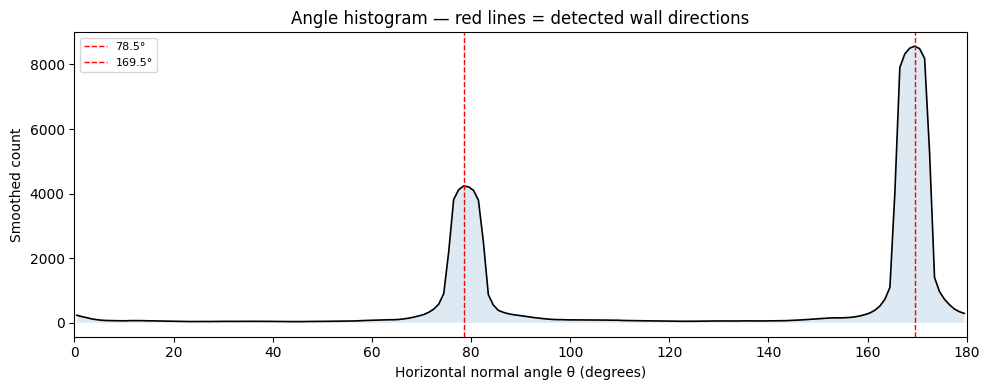

In [34]:
if walls and '_theta_smooth' in walls[0]:
    smoothed = walls[0]['_theta_smooth']
    bin_centres = walls[0]['_theta_centres']
    peak_centres = walls[0]['_theta_peaks']

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(np.degrees(bin_centres), smoothed, 'k-', lw=1.2)
    ax.fill_between(np.degrees(bin_centres), smoothed, alpha=0.15)
    for p in peak_centres:
        ax.axvline(np.degrees(p), color='red', ls='--', lw=1,
                   label=f'{np.degrees(p):.1f}°')
    ax.set_xlabel('Horizontal normal angle θ (degrees)')
    ax.set_ylabel('Smoothed count')
    ax.set_title('Angle histogram — red lines = detected wall directions')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 180)
    plt.tight_layout()
    plt.show()
else:
    print("No diagnostic data — re-run the segment_walls cell above.")

### 3.3 Visualise

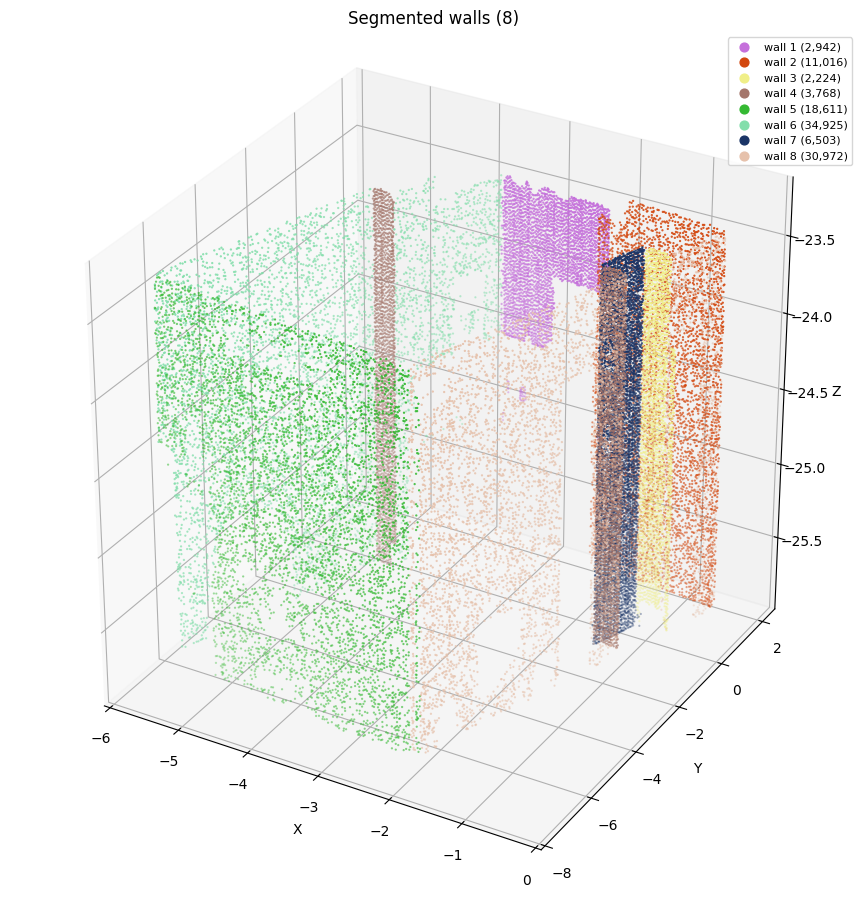

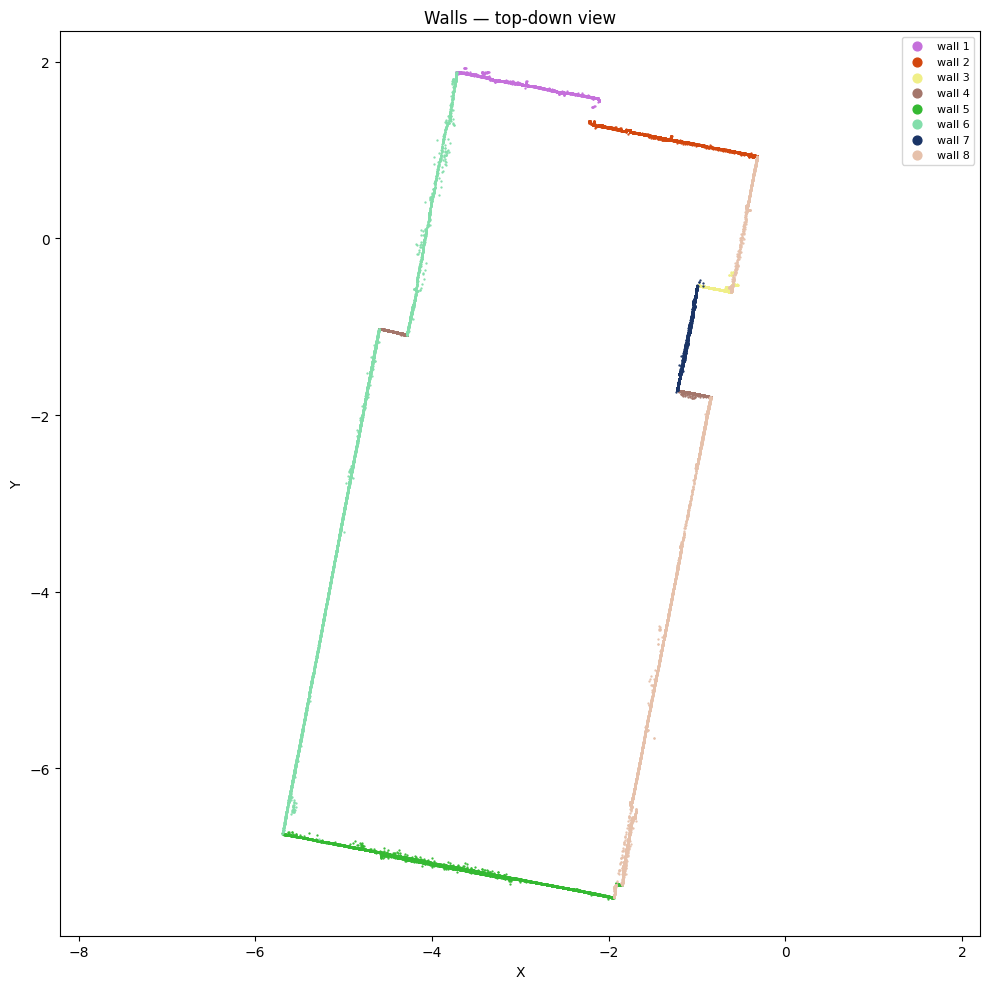

In [35]:
plot_walls_3d(walls, up_axis=CFG.up_axis)
plot_walls_topdown(walls, up_axis=CFG.up_axis)

### 3.4 Save wall frontal images (clean, no axes)

Saves raw binary PNGs (black = wall, white = void) into per-room folders:
```
out_dir/
  room_01/
    wall_01.png
    wall_02.png
    ...
  room_02/
    ...
```
Use `plot_wall_images()` separately if you want the annotated matplotlib preview.

In [ ]:
# extract room name from the loaded file
room_name = os.path.splitext(os.path.basename(CFG.file_path))[0]  # e.g. "room_01_walls"
room_name = room_name.replace('_walls', '')                        # e.g. "room_01"

flats = save_wall_images(
    walls, room_name, CFG.out_dir,
    up_axis=CFG.up_axis,
    pixel_m=CFG.flat_pixel_m,
)

for i, f in enumerate(flats):
    print(f"    wall_{i+1:02d}.png: {f['image'].shape[1]} × {f['image'].shape[0]} px  "
          f"({f['width_m']:.2f} × {f['height_m']:.2f} m)")

### 3.5 Export per-wall clouds

In [ ]:
os.makedirs(CFG.out_dir, exist_ok=True)
rng = np.random.default_rng(0)

combined_pts, combined_cols = [], []
for i, w in enumerate(walls):
    pts = np.asarray(w['cloud'].points)
    path = os.path.join(CFG.out_dir, f"wall_{i+1:02d}.ply")
    o3d.io.write_point_cloud(path, w['cloud'])
    print(f"  {os.path.basename(path)}: {len(pts):,} points")

    combined_pts.append(pts)
    combined_cols.append(np.tile(rng.random(3), (len(pts), 1)))

if combined_pts:
    combined = o3d.geometry.PointCloud()
    combined.points = o3d.utility.Vector3dVector(np.vstack(combined_pts))
    combined.colors = o3d.utility.Vector3dVector(np.vstack(combined_cols))
    combined_path = os.path.join(CFG.out_dir, "all_walls_colored.ply")
    o3d.io.write_point_cloud(combined_path, combined)
    print(f"\n  {os.path.basename(combined_path)}: {len(combined.points):,} points (QC)")

print(f"\nOutput directory: {CFG.out_dir}")
print("Files:", sorted(os.listdir(CFG.out_dir)))

### 3.6 Batch: process ALL rooms

Loops over every `room_*_walls.ply` matched by `CFG.room_glob`, segments
walls, and saves clean frontal PNGs into per-room subfolders.

In [ ]:
room_files = sorted(glob.glob(CFG.room_glob))
print(f"Found {len(room_files)} room files matching: {CFG.room_glob}\n")

all_results = {}
for room_path in room_files:
    fname = os.path.splitext(os.path.basename(room_path))[0]
    room_name = fname.replace('_walls', '')

    print(f"{'='*60}")
    print(f"Processing {room_name}  ({os.path.basename(room_path)})")
    print(f"{'='*60}")

    try:
        room_pcd, _ = load_room_cloud(room_path, voxel_m=CFG.voxel_m)

        room_walls = segment_walls(
            room_pcd,
            up_axis=CFG.up_axis,
            normal_tol_deg=CFG.normal_tol_deg,
            angle_tol_deg=CFG.angle_tol_deg,
            offset_tol=CFG.offset_tol_m,
            min_wall_points=CFG.min_wall_points,
            normal_radius=CFG.normal_radius_m,
            normal_max_nn=CFG.normal_max_nn,
        )

        if room_walls:
            room_flats = save_wall_images(
                room_walls, room_name, CFG.out_dir,
                up_axis=CFG.up_axis,
                pixel_m=CFG.flat_pixel_m,
            )
            all_results[room_name] = room_flats
        else:
            print(f"  (no walls segmented, skipping)")

    except Exception as e:
        print(f"  ERROR: {e}")

    print()

# summary
print(f"\n{'='*60}")
print(f"DONE — {len(all_results)} rooms processed")
print(f"Output: {CFG.out_dir}")
total_imgs = sum(len(v) for v in all_results.values())
print(f"Total wall images: {total_imgs}")
for rn, fl in sorted(all_results.items()):
    print(f"  {rn}/: {len(fl)} walls")